# Example Notebook

In [26]:
## Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cmocean
import sys
import os
import glob

sys.path.append(os.getcwd())
from utils import load_grid_vertex, plot_map2d, read_variables, read_compound_name


In [27]:

data_root='/scratch/yanchun/cmorout'

source_id      = "DUMMY-MODEL"
experiment_id  = "piControl"
variant_label  = "r1i1p1f1"
grid_label     = "g999"
version        = "v20260601"

In [28]:
# data path
data_path = os.path.join(data_root, source_id, experiment_id, version)

# load grid
grid_file = 'data/grid.nc'
lat, lon, clat, clon = load_grid_vertex(grid_file)
with xr.open_dataset(grid_file) as ds:
    pmask = ds['pmask'].values
    parea = ds['parea'].values

# load methods for plotting and set defaults
methods =read_variables('data/methods.txt')


**List of data to be validated**

In [29]:
# load compound names

cnames = read_compound_name()
cnames = ['ocean.thetao.tavg-ol-hxy-sea.mon.glb', 'ocean.masscello.tavg-ol-hxy-sea.mon.glb']
for cname in cnames:
    print(cname)


ocean.thetao.tavg-ol-hxy-sea.mon.glb
ocean.masscello.tavg-ol-hxy-sea.mon.glb


ocean.thetao.tavg-ol-hxy-sea.mon.glb
Sea Water Potential Temperature (degC)
lat/lon plot, vertical method: mean
Timeseries plot, aggregation method: mean


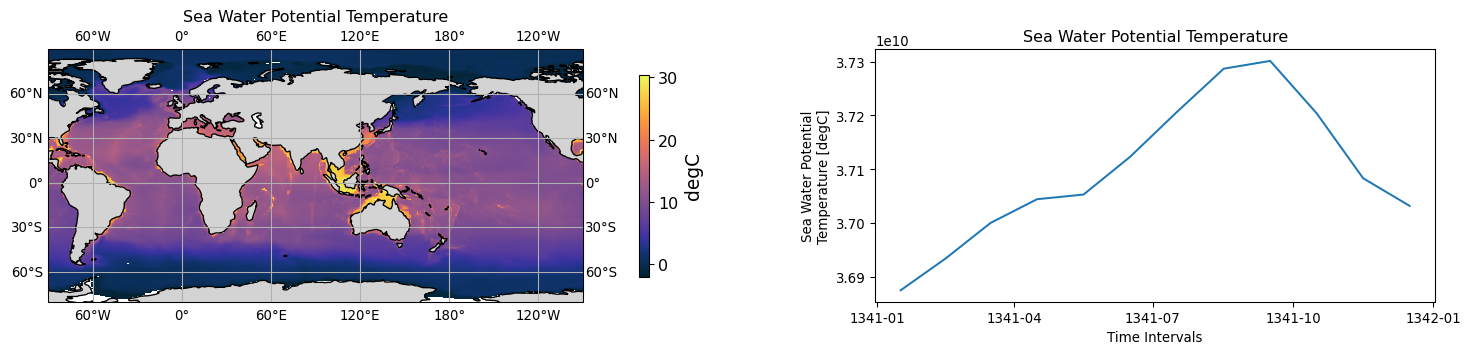

ocean.masscello.tavg-ol-hxy-sea.mon.glb
Ocean Grid-Cell Mass per Area (kg m-2)
lat/lon plot, vertical method: sum
Timeseries plot, aggregation method: sum


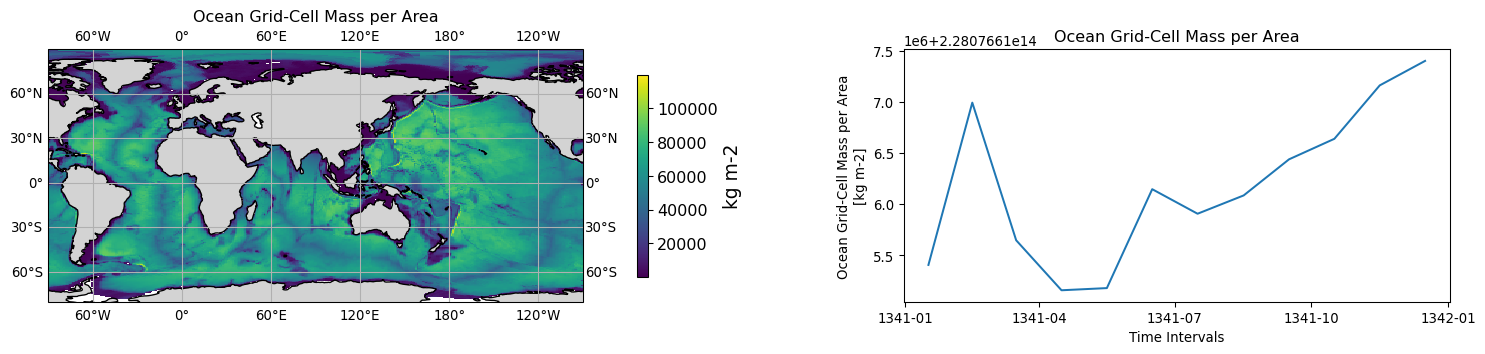

In [ ]:

for cname in cnames:
    if 'vertical' in methods[cname].keys():
        mth_vert = methods[cname]['vertical']
    else:
        mth_vert = 'mean'

    if 'timeseries' in methods[cname].keys():
        mth_ts = methods[cname]['timeseries']
    else:
        mth_ts = 'mean'

    if 'cmap' in methods[cname].keys():
        mth_cmap = methods[cname]['cmap']
    else:
        mth_cmap = 'mpl.colormaps["viridis"]'

    var = cname.split('.')[1]
    coord = cname.split('.')[2]
    grid = 'g999'

    if coord != 'tavg-ol-hxy-sea':
        continue

    #data_file = 'masscello_tavg-ol-hxy-sea_mon_glb_g999_DUMMY-MODEL_piControl_r1i1p1f1_134101-134112.nc'
    data_file = var+'_'+coord+'_*_'+grid+'_'+source_id+'_'+experiment_id+'_'+variant_label+'_*.nc'

    if not glob.glob(os.path.join(data_path, data_file)):
        continue

    #with xr.open_dataset(os.path.join(data_path, data_file)) as ds:
    with xr.open_mfdataset(os.path.join(data_path, data_file)) as ds:
        if var in ds:
            data = ds[var]
        else:
            continue

    data2d = data.mean(dim='lev').where(pmask == 1)

    print(f'{cname}')
    print(f'{data2d.long_name} ({data2d.units})')
    print(f'vertical aggregation method for 2D plot: {mth_vert}')
    print(f'timeseries aggregation method for 1D plot: {mth_ts}')

    fig = plt.figure(figsize=(16, 3), dpi=96)
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[2, 1]) 
    proj = ccrs.PlateCarree(central_longitude=90.0)

    ax1 = fig.add_subplot(gs[0], projection=proj)
    #ax1 = fig.add_subplot(1, 2, 1, projection=proj)
    #fig, (ax1, ax2) = plt.subplots( nrows=1, ncols=2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]}, subplot_kw={'projection': proj})

    # Plot the mesh
    pm = ax1.pcolormesh(lon, lat, data2d.mean(dim='time'), cmap=eval(mth_cmap), norm=None,
                        transform=ccrs.PlateCarree(), shading='auto', rasterized=True)

    # Add map features
    #ax.stock_img()
    ax1.add_feature(cfeature.LAND, facecolor='lightgray')

    gl = ax1.gridlines(ylocs=range(-90, 90, 30), draw_labels=True)
    gl.ylocator = mpl.ticker.FixedLocator(range(-90,90,30))

    # Add colorbar
    cb = plt.colorbar(pm, ax=ax1, fraction=0.4, shrink=0.8, label='[yr]')
    cb.set_label(label=data.units, size=14)
    cb.ax.tick_params(labelsize=12)
    plt.tight_layout()
    
    
    #fig, ax = plot_map2d(lon, lat, data2d.mean(dim='time'), proj='PlateCarree', norm=None, cmap=eval(mth_cmap))
    ax1.coastlines(resolution='110m')
    ax1.add_feature(cfeature.LAND, facecolor='lightgray')
    plt.title(data2d.long_name)
    #plt.show()

    data1d = (data2d*parea).mean(dim=['j', 'i'])
  
    
    #fig1d = plt.figure()
    ax2 = fig.add_subplot(gs[1])
    data1d.plot(ax=ax2)
    plt.title(data1d.long_name)
    plt.show()

